In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("../data/Walmart.csv")

In [23]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [24]:
df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [25]:
df.shape

(6435, 8)

In [26]:
df.columns


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [28]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [29]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [33]:
print(df["Date"].min())
print(df["Date"].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


In [34]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

In [35]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_Name
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,February
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,February
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,February
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,February
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,March


In [36]:
df["Weekly_Sales"].sum()

np.float64(6737218987.11)

In [37]:
df["Weekly_Sales"].mean()

np.float64(1046964.8775617715)

In [38]:
df["Weekly_Sales"].max()

np.float64(3818686.45)

In [39]:
df["Weekly_Sales"].min()

np.float64(209986.25)

In [40]:
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

store_sales.head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

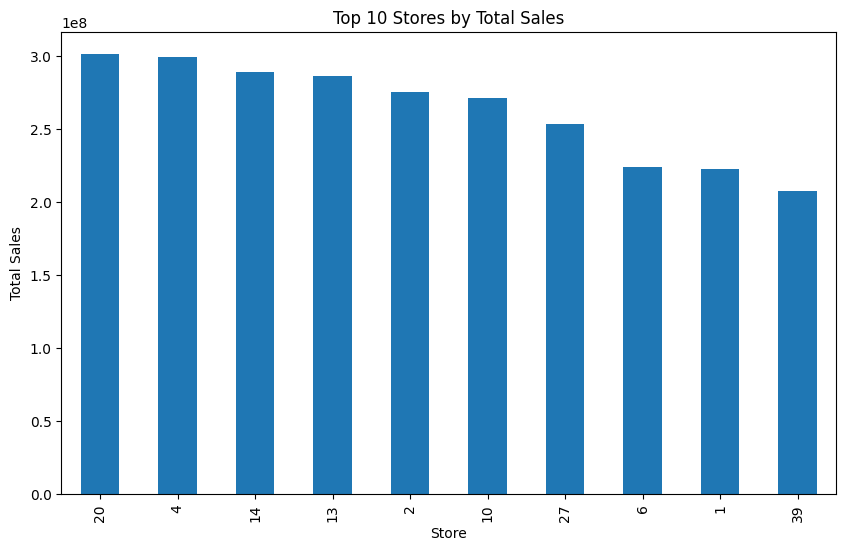

In [41]:
plt.figure(figsize=(10,6))

store_sales.head(10).plot(kind="bar")

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.show()

In [42]:
monthly_sales = df.groupby("Month_Name")["Weekly_Sales"].sum()

monthly_sales

Month_Name
April        6.468598e+08
August       6.130902e+08
December     5.768386e+08
February     5.687279e+08
January      3.325984e+08
July         6.500010e+08
June         6.226299e+08
March        5.927859e+08
May          5.571256e+08
November     4.130157e+08
October      5.847848e+08
September    5.787612e+08
Name: Weekly_Sales, dtype: float64

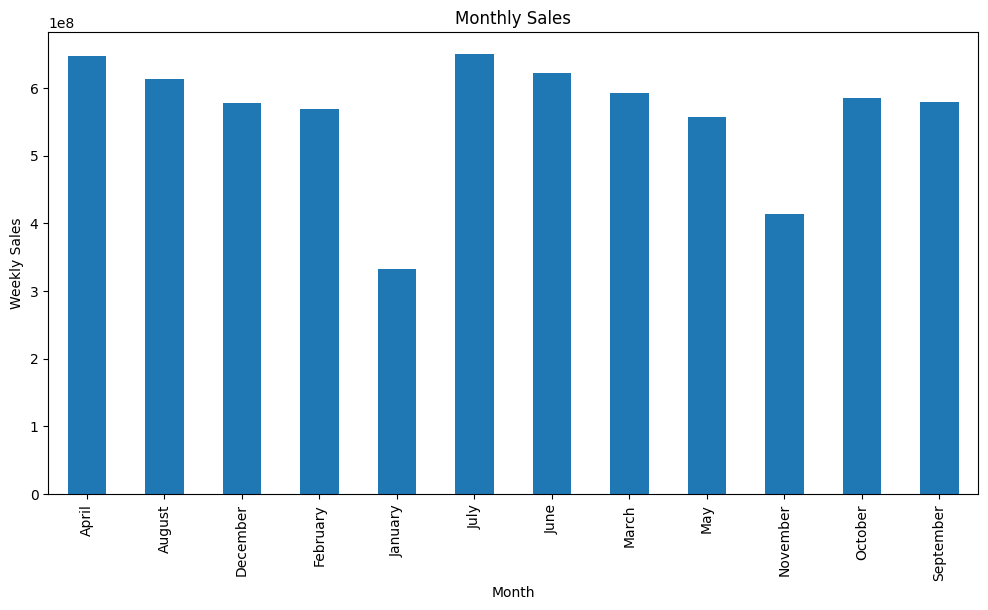

In [43]:
plt.figure(figsize=(12,6))

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Weekly Sales")

plt.show()

In [44]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

holiday_sales

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

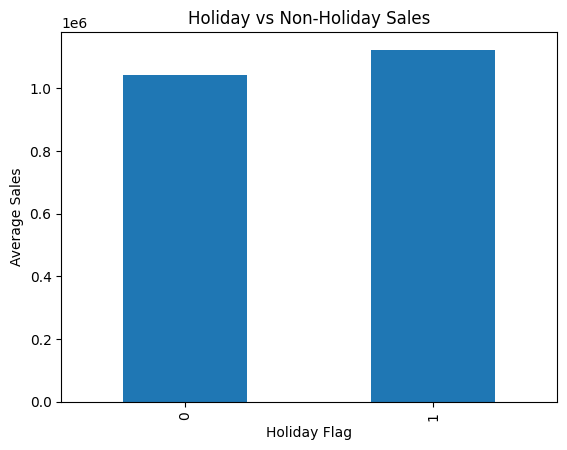

In [45]:
holiday_sales.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Sales")

plt.show()

In [46]:
correlation = df.corr(numeric_only=True)

correlation

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
Store,1.000000e+00,-0.335332,-4.735625e-16,-0.022659,0.060023,-0.209492,0.223531,3.474332e-12,2.920358e-15
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176,-1.837754e-02,7.614332e-02
Holiday_Flag,-4.735625e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960,-5.678257e-02,1.229958e-01
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158,6.426923e-02,2.358618e-01
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684,7.794703e-01,-4.215590e-02
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020,7.479573e-02,4.979672e-03
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000,-2.418135e-01,-1.274559e-02
Year,3.474332e-12,-0.018378,-5.678257e-02,0.064269,0.779470,0.074796,-0.241813,1.000000e+00,-1.944645e-01
Month,2.920358e-15,0.076143,1.229958e-01,0.235862,-0.042156,0.004980,-0.012746,-1.944645e-01,1.000000e+00


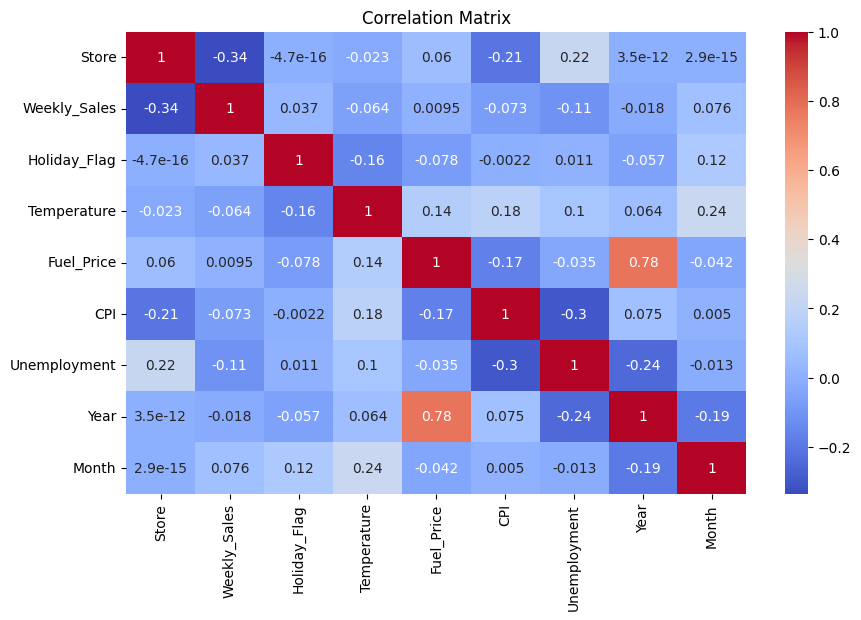

In [47]:
plt.figure(figsize=(10,6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

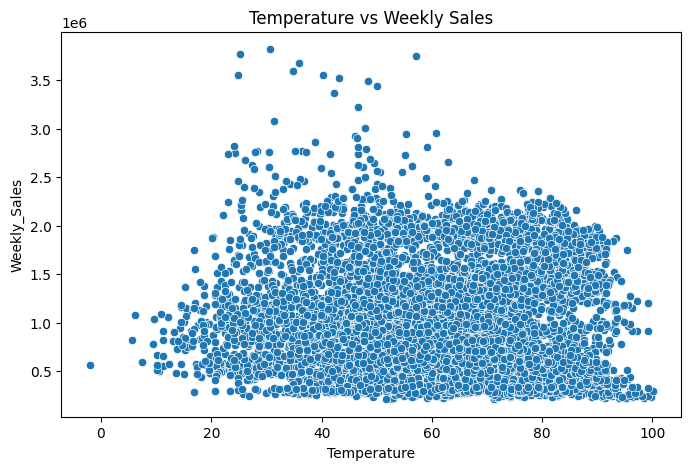

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Temperature", y="Weekly_Sales", data=df)

plt.title("Temperature vs Weekly Sales")

plt.show()

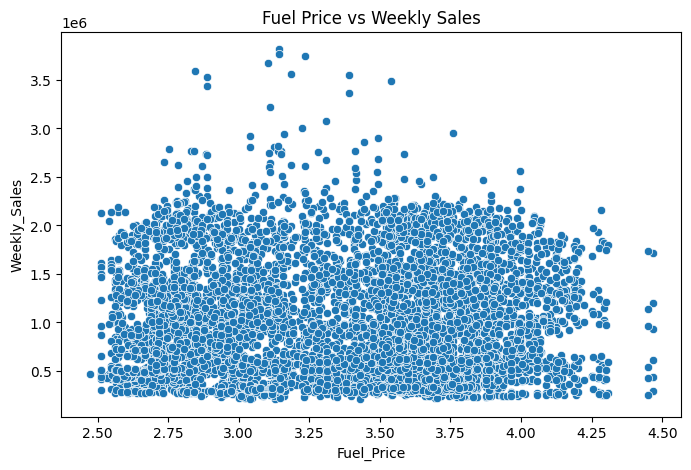

In [49]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Fuel_Price", y="Weekly_Sales", data=df)

plt.title("Fuel Price vs Weekly Sales")

plt.show()

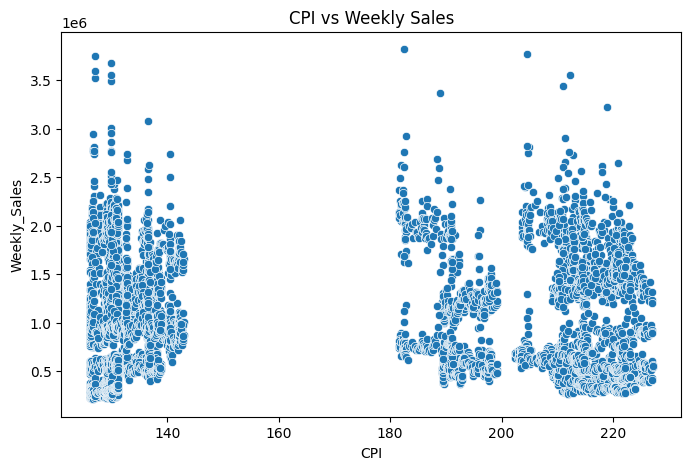

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="CPI", y="Weekly_Sales", data=df)

plt.title("CPI vs Weekly Sales")

plt.show()

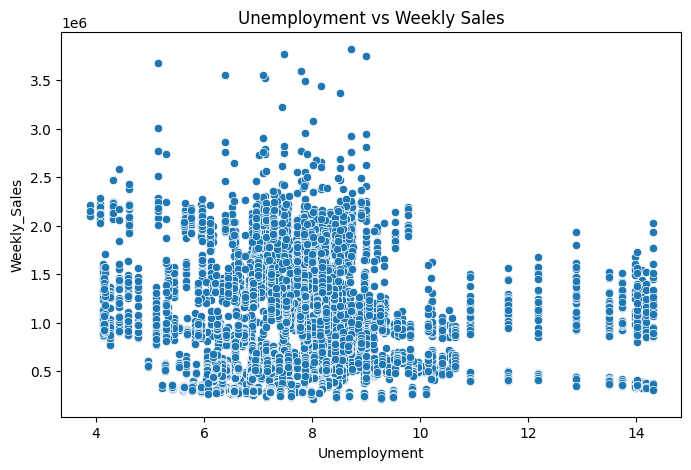

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Unemployment", y="Weekly_Sales", data=df)

plt.title("Unemployment vs Weekly Sales")

plt.show()

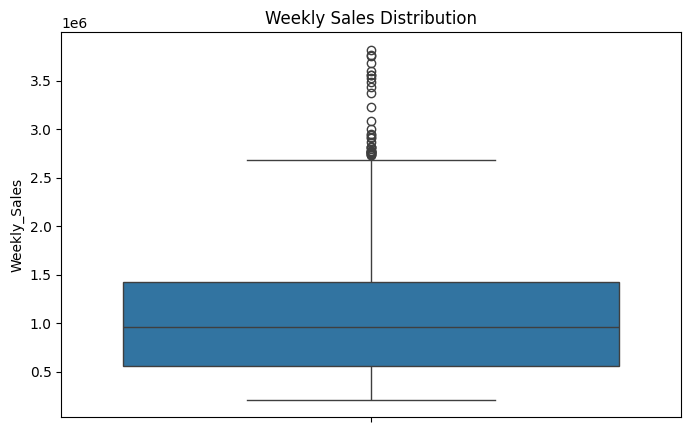

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Weekly_Sales"])

plt.title("Weekly Sales Distribution")

plt.show()

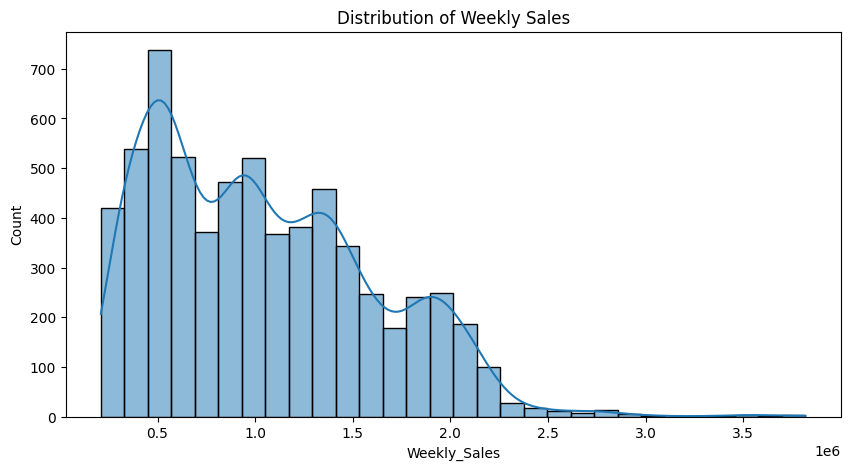

In [53]:
plt.figure(figsize=(10,5))

sns.histplot(df["Weekly_Sales"], bins=30, kde=True)

plt.title("Distribution of Weekly Sales")

plt.show()

In [54]:
total_sales = df["Weekly_Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 6737218987.11


In [55]:
avg_sales = df["Weekly_Sales"].mean()
print("Average Weekly Sales:", avg_sales)

Average Weekly Sales: 1046964.8775617715


In [56]:
highest_sales = df["Weekly_Sales"].max()
print("Highest Weekly Sales:", highest_sales)

Highest Weekly Sales: 3818686.45


In [57]:
lowest_sales = df["Weekly_Sales"].min()
print("Lowest Weekly Sales:", lowest_sales)

Lowest Weekly Sales: 209986.25


In [58]:
total_stores = df["Store"].nunique()
print("Total Stores:", total_stores)

Total Stores: 45


In [59]:
best_store = df.groupby("Store")["Weekly_Sales"].sum().idxmax()
print("Best Store:", best_store)

Best Store: 20


In [60]:
best_month = df.groupby("Month_Name")["Weekly_Sales"].sum().idxmax()
print("Best Month:", best_month)

Best Month: July


In [61]:
holiday_sales = df[df["Holiday_Flag"] == 1]["Weekly_Sales"].sum()
print("Holiday Sales:", holiday_sales)

Holiday Sales: 505299551.56


In [62]:
non_holiday_sales = df[df["Holiday_Flag"] == 0]["Weekly_Sales"].sum()
print("Non-Holiday Sales:", non_holiday_sales)

Non-Holiday Sales: 6231919435.55


In [63]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Average Weekly Sales",
        "Highest Weekly Sales",
        "Lowest Weekly Sales",
        "Total Stores",
        "Best Store",
        "Best Month",
        "Holiday Sales",
        "Non-Holiday Sales"
    ],
    "Value": [
        total_sales,
        avg_sales,
        highest_sales,
        lowest_sales,
        total_stores,
        best_store,
        best_month,
        holiday_sales,
        non_holiday_sales
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,6737218987.11
1,Average Weekly Sales,1046964.877562
2,Highest Weekly Sales,3818686.45
3,Lowest Weekly Sales,209986.25
4,Total Stores,45
5,Best Store,20
6,Best Month,July
7,Holiday Sales,505299551.56
8,Non-Holiday Sales,6231919435.55


In [64]:
df.to_csv("../data/Walmart_Cleaned.csv", index=False)

In [65]:
kpi_summary.to_csv("../data/KPI_Summary.csv", index=False)

In [66]:
plt.savefig("../images/top_10_stores.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [67]:
plt.savefig("../images/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [68]:
plt.savefig("../images/holiday_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [69]:
plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [70]:
plt.savefig("../images/temperature_vs_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [71]:
plt.savefig("../images/fuel_price_vs_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [72]:
plt.savefig("../images/cpi_vs_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [73]:
plt.savefig("../images/unemployment_vs_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [74]:
plt.savefig("../images/weekly_sales_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [75]:
plt.savefig("../images/weekly_sales_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

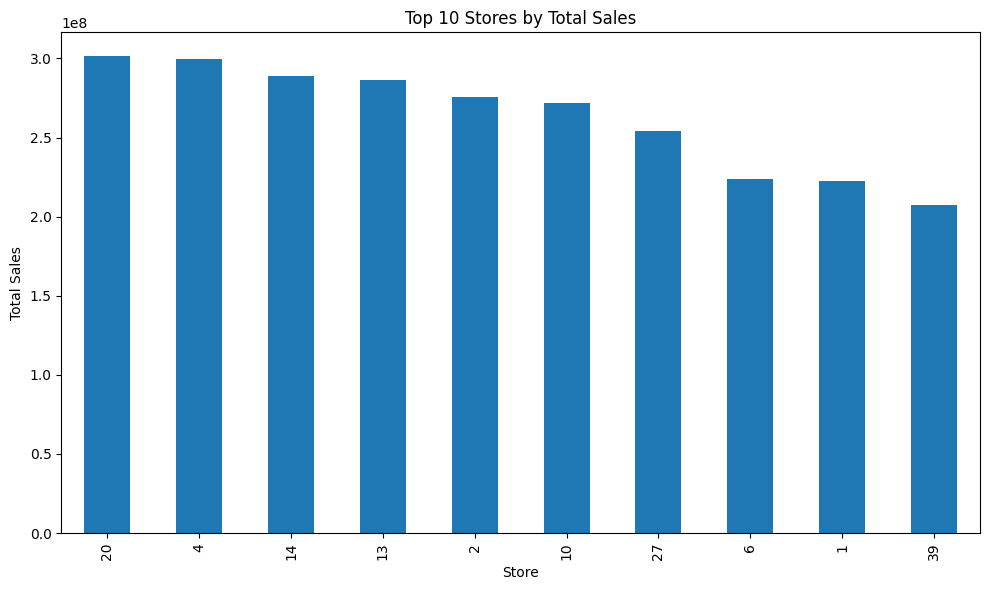

In [76]:
plt.figure(figsize=(10,6))

store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

store_sales.head(10).plot(kind="bar")

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("../images/top_10_stores.png", dpi=300)

plt.show()

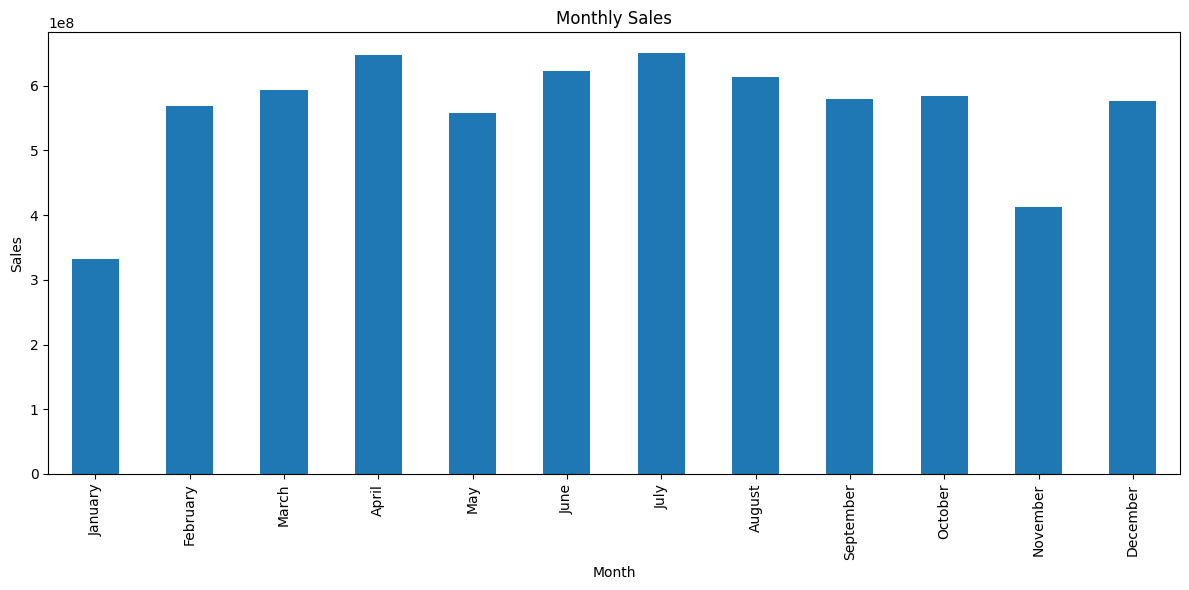

In [77]:
plt.figure(figsize=(12,6))

monthly_sales = df.groupby("Month_Name")["Weekly_Sales"].sum()

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../images/monthly_sales.png", dpi=300)

plt.show()

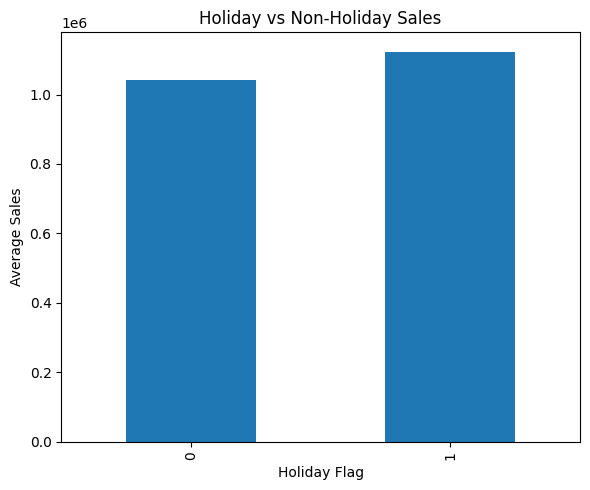

In [78]:
plt.figure(figsize=(6,5))

holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

holiday_sales.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.savefig("../images/holiday_sales.png", dpi=300)

plt.show()

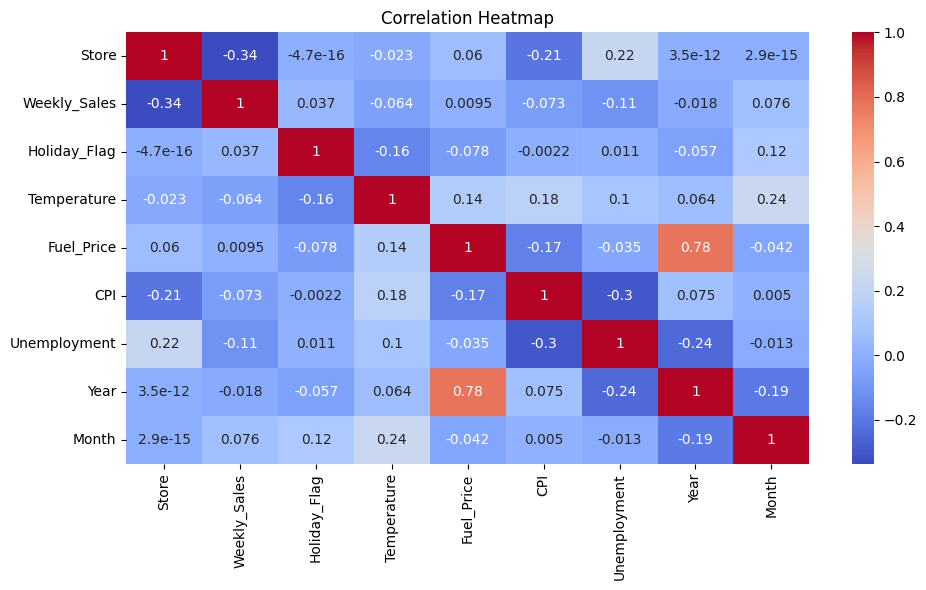

In [79]:
plt.figure(figsize=(10,6))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=300)

plt.show()

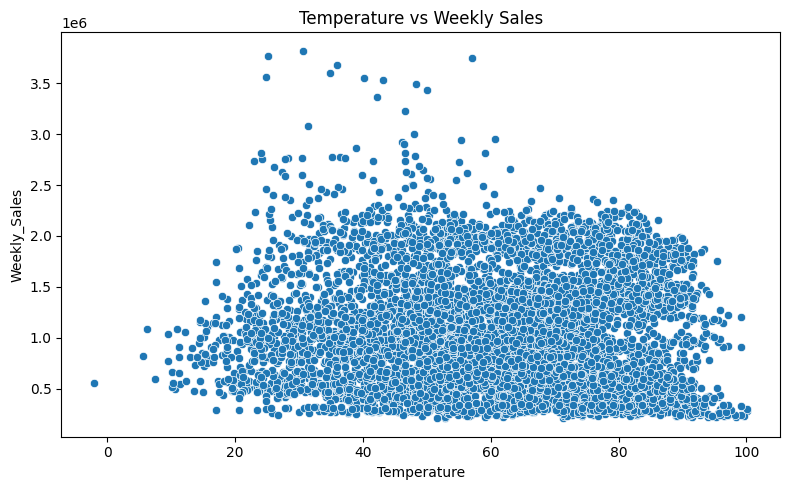

In [80]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Temperature", y="Weekly_Sales")

plt.title("Temperature vs Weekly Sales")

plt.tight_layout()
plt.savefig("../images/temperature_vs_sales.png", dpi=300)

plt.show()

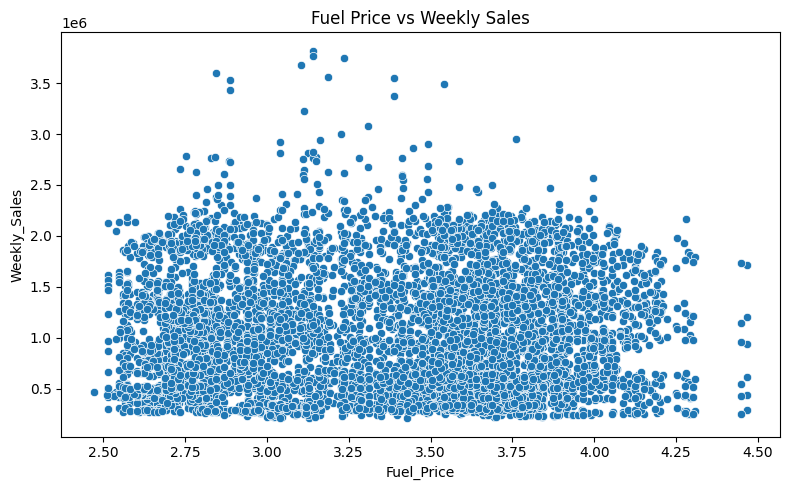

In [81]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Fuel_Price", y="Weekly_Sales")

plt.title("Fuel Price vs Weekly Sales")

plt.tight_layout()
plt.savefig("../images/fuel_price_vs_sales.png", dpi=300)

plt.show()

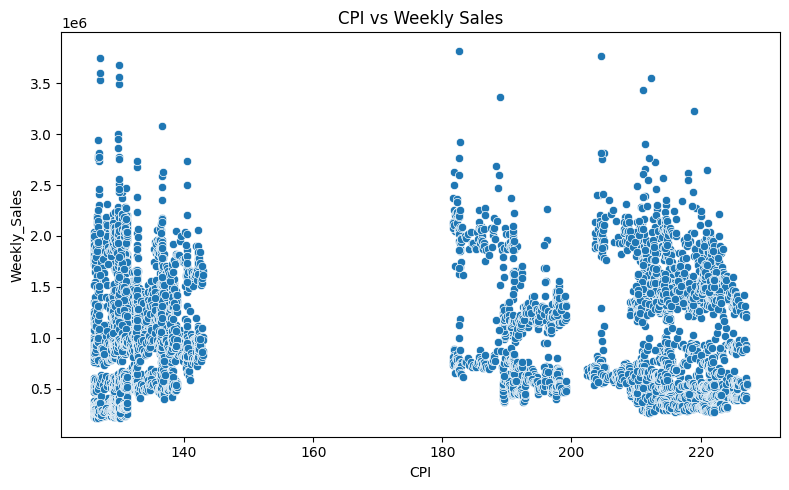

In [82]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="CPI", y="Weekly_Sales")

plt.title("CPI vs Weekly Sales")

plt.tight_layout()
plt.savefig("../images/cpi_vs_sales.png", dpi=300)

plt.show()

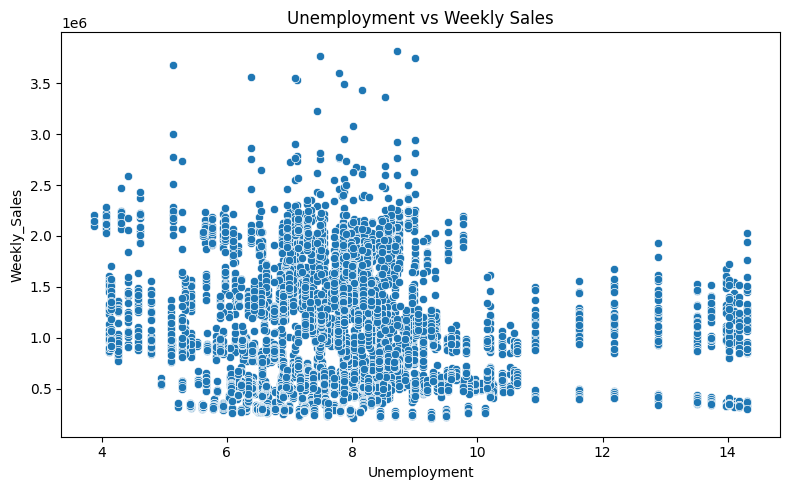

In [83]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Unemployment", y="Weekly_Sales")

plt.title("Unemployment vs Weekly Sales")

plt.tight_layout()
plt.savefig("../images/unemployment_vs_sales.png", dpi=300)

plt.show()

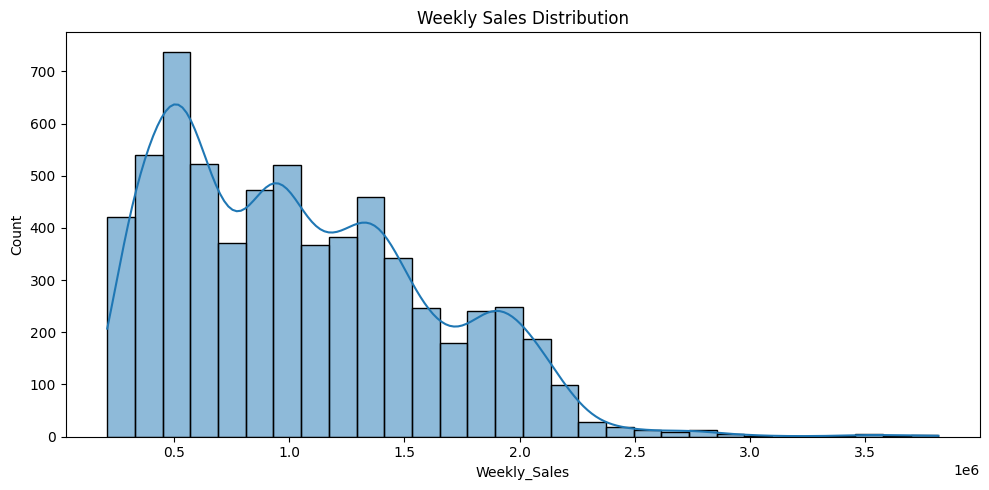

In [84]:
plt.figure(figsize=(10,5))

sns.histplot(df["Weekly_Sales"], bins=30, kde=True)

plt.title("Weekly Sales Distribution")

plt.tight_layout()
plt.savefig("../images/weekly_sales_distribution.png", dpi=300)

plt.show()

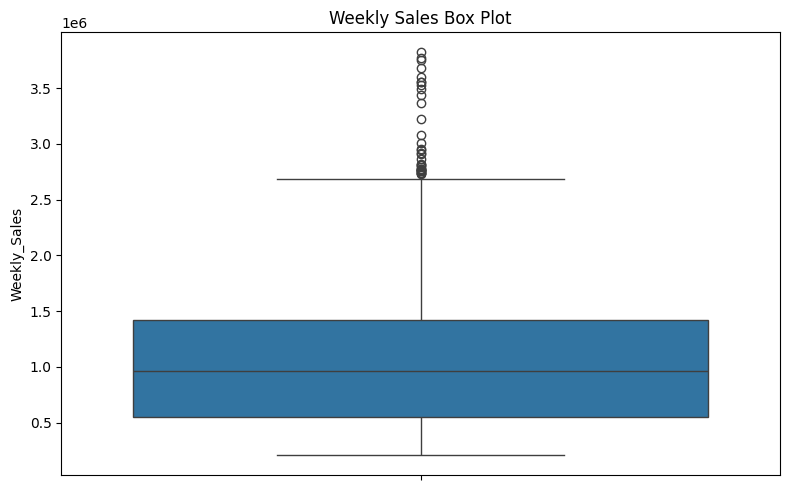

In [85]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Weekly_Sales"])

plt.title("Weekly Sales Box Plot")

plt.tight_layout()
plt.savefig("../images/weekly_sales_boxplot.png", dpi=300)

plt.show()